#📌 Extracão

In [106]:
import pandas as pd
import requests

# Passo 1: Carregar os dados da API
url_da_api = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json"

def carregar_dados(url):
    try:
        print("Tentando extrair dados enquanto minha paciência ainda existe...")
        response = requests.get(url)

        # Verifica se a API não nos deu um erro 404 ou 500
        response.raise_for_status()

        # Passo 2: Converter para DataFrame
        # O .json() transforma a string de resposta em um dicionário/lista Python
        dados_json = response.json()
        df = pd.DataFrame(dados_json)

        print("Sucesso. Os dados foram capturados. (In)felizmente, agora tem que analisá-los.")
        return df

    except Exception as e:
        print(f"Algo deu errado (surpresa zero): {e}")
        return None

# Execução
df_telecom = carregar_dados(url_da_api)

Tentando extrair dados enquanto minha paciência ainda existe...
Sucesso. Os dados foram capturados. (In)felizmente, agora tem que analisá-los.


#🔧 Transformação

In [107]:
# Supondo que já carregou o df_telecom na etapa anterior
print("--- Resumo Técnico do Dataset ---")
# O .info() é o raio-X que mostra onde o dataset está quebrado
df_telecom.info()

print("\n--- Primeiras Linhas ---")
# Olhar para os dados para garantir que não são apenas hieróglifos
print(df_telecom.head())

# Identificando colunas cruciais para a análise de Churn (Evasão)
# Baseado no dicionário que você tem:
colunas_relevantes = [
    'Churn',             # A variável alvo (quem saiu)
    'Meses_Contrato',    # Fidelidade
    'CobrancasMensais',  # O peso no bolso do cliente
    'Tipo_Contrato',     # O nível da "prisão" contratual
    'Internet',          # O serviço que provavelmente falha
    'Pagamento_Online'   # O método de pagamento
]

print(f"\nFocaremos nestas colunas para salvar a empresa do desastre: {colunas_relevantes}")

--- Resumo Técnico do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB

--- Primeiras Linhas ---
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                           

In [108]:

# Supondo que df_telecom já existe com as colunas aninhadas
def achatar_dados(df):
    print("Iniciando a sessão: achatando colunas aninhadas...")

    # Lista das colunas que são dicionários
    colunas_para_expandir = ['customer', 'phone', 'internet', 'account']

    # Criamos uma lista com o ID e o Churn para servir de base
    df_base = df[['customerID', 'Churn']].copy()

    dfs_expandidos = [df_base]

    for col in colunas_para_expandir:
        # O json_normalize transforma dicionários em colunas reais
        expandido = pd.json_normalize(df[col])
        dfs_expandidos.append(expandido)

    # Juntamos tudo de volta lateralmente (axis=1)
    df_final = pd.concat(dfs_expandidos, axis=1)

    print("Transformação concluída. Agora temos colunas de verdade.")
    return df_final

# Aplicando a transformação
df_limpo = achatar_dados(df_telecom)

# Agora sim, pode ver o que realmente importa
print(df_limpo.info())
print(df_limpo[['customerID', 'Churn', 'Contract', 'Charges.Monthly']].head())

Iniciando a sessão: achatando colunas aninhadas...
Transformação concluída. Agora temos colunas de verdade.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-n

In [109]:

# 1. Caça às Duplicatas
# Se houver duplicatas, elas estão apenas ocupando memória preciosa.
total_duplicatas = df_limpo.duplicated().sum()
print(f"Linhas duplicadas encontradas: {total_duplicatas}")

# 2. O Mistério do Churn e outras categorias
# Usando unique() como o backlog sugeriu para ver se há 'lixo' nas categorias.
print("\nValores únicos em 'Churn':", df_limpo['Churn'].unique())
print("Valores únicos em 'Contract':", df_limpo['Contract'].unique())

# 3. O Problema do "Espaço em Branco"
# Muitas vezes, dados não estão 'nulos' (NaN), mas sim com uma string vazia " ".
# Isso é comum em Charges.Total quando o cliente acabou de assinar (tenure = 0).
espacos_vazios = df_limpo[df_limpo['Charges.Total'] == ' '].shape[0]
print(f"\nClientes com 'espaço vazio' em Charges.Total: {espacos_vazios}")

# 4. Verificação de Nulos Reais
print("\nResumo de valores ausentes (NaN):")
print(df_limpo.isnull().sum())

Linhas duplicadas encontradas: 0

Valores únicos em 'Churn': ['No' 'Yes' '']
Valores únicos em 'Contract': ['One year' 'Month-to-month' 'Two year']

Clientes com 'espaço vazio' em Charges.Total: 11

Resumo de valores ausentes (NaN):
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


In [110]:
# 1. Removendo linhas com Churn vazio (o inimigo número 1 da análise)
# Se o Churn for uma string vazia ou apenas espaços, nós o descartamos.
df_limpo = df_limpo[df_limpo['Churn'] != ''].copy()

# 2. Convertendo Charges.Total para numérico
# O 'errors=coerce' transforma os " " em NaN de verdade, que o Pandas entende.
df_limpo['Charges.Total'] = pd.to_numeric(df_limpo['Charges.Total'], errors='coerce')

# 3. Lidando com os novos NaNs em Charges.Total
# Como são poucos e provavelmente de clientes com tenure 0, vamos preencher com 0.
df_limpo['Charges.Total'] = df_limpo['Charges.Total'].fillna(0)

# 4. Verificação final (Desta vez, a verdade aparecerá)
print("--- Verificação Pós-Limpeza ---")
print(f"Valores únicos em Churn: {df_limpo['Churn'].unique()}")
print(f"Nulos em Charges.Total: {df_limpo['Charges.Total'].isnull().sum()}")
print(f"Tamanho final do dataset: {df_limpo.shape}")

--- Verificação Pós-Limpeza ---
Valores únicos em Churn: ['No' 'Yes']
Nulos em Charges.Total: 0
Tamanho final do dataset: (7043, 21)


In [111]:
# 1. Tradução e Renomeação (Tornando os dados compreensíveis)
# Baseado no seu dicionário e backlog
traducao_colunas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasao',
    'gender': 'Genero',
    'SeniorCitizen': 'Idoso',
    'Partner': 'Parceiro',
    'Dependents': 'Dependentes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servico_Telefonico',
    'MultipleLines': 'Multiplas_Linhas',
    'InternetService': 'Provedor_Internet',
    'OnlineSecurity': 'Seguranca_Online',
    'OnlineBackup': 'Backup_Online',
    'DeviceProtection': 'Protecao_Dispositivo',
    'TechSupport': 'Suporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Filmes',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Fatura_Online',
    'PaymentMethod': 'Forma_Pagamento',
    'Charges.Monthly': 'Faturamento_Mensal',
    'Charges.Total': 'Faturamento_Total'
}

df_limpo = df_limpo.rename(columns=traducao_colunas)

# 2. Criando a coluna Contas_Diarias
# O faturamento mensal é o total de serviços por mês
df_limpo['Contas_Diarias'] = (df_limpo['Faturamento_Mensal'] / 30).round(2)

# 3. Transformação Binária (Standardization)
# Convertendo 'Yes'/'No' para 1/0 para facilitar a análise
mapeamento_binario = {'Yes': 1, 'No': 0}
df_limpo['Evasao_Binaria'] = df_limpo['Evasao'].map(mapeamento_binario)

# Verificando se a "mágica" aconteceu
print("--- Amostra dos Dados Padronizados ---")
print(df_limpo[['Evasao', 'Evasao_Binaria', 'Faturamento_Mensal', 'Contas_Diarias']].head())

--- Amostra dos Dados Padronizados ---
  Evasao  Evasao_Binaria  Faturamento_Mensal  Contas_Diarias
0     No               0                65.6            2.19
1     No               0                59.9            2.00
2    Yes               1                73.9            2.46
3    Yes               1                98.0            3.27
4    Yes               1                83.9            2.80


#📊 Carga e análise

In [112]:
analise_estatistica = df_limpo.describe()
print(analise_estatistica)

             Idoso  Meses_Contrato  Faturamento_Mensal  Faturamento_Total  \
count  7043.000000     7043.000000         7043.000000        7043.000000   
mean      0.162147       32.371149           64.761692        2279.734304   
std       0.368612       24.559481           30.090047        2266.794470   
min       0.000000        0.000000           18.250000           0.000000   
25%       0.000000        9.000000           35.500000         398.550000   
50%       0.000000       29.000000           70.350000        1394.550000   
75%       0.000000       55.000000           89.850000        3786.600000   
max       1.000000       72.000000          118.750000        8684.800000   

       Contas_Diarias  Evasao_Binaria  
count     7043.000000     7043.000000  
mean         2.158675        0.265370  
std          1.003088        0.441561  
min          0.610000        0.000000  
25%          1.180000        0.000000  
50%          2.340000        0.000000  
75%          2.990000     

/tmp/ipykernel_169/2467803320.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_limpo, x='Evasao', palette={'No': 'seagreen', 'Yes': 'crimson'})


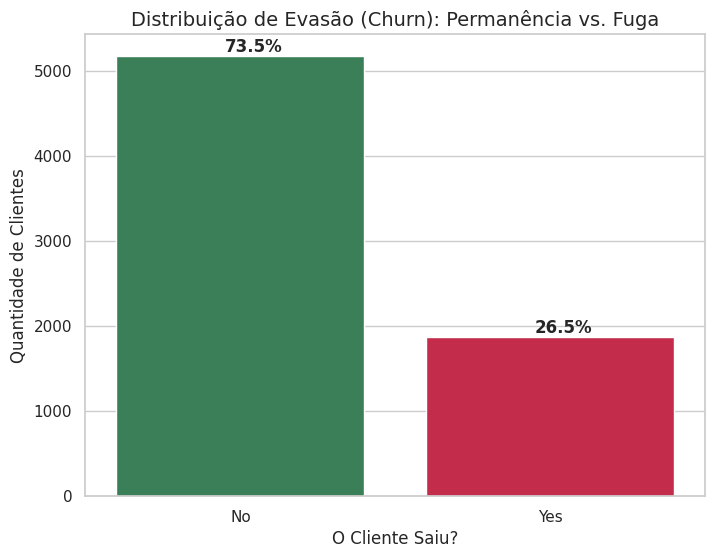

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurando o estilo para parecer profissional, apesar do caos
sns.set_theme(style="whitegrid")

# Criando a figura
plt.figure(figsize=(8, 6))

# Gerando o gráfico de contagem (Count Plot)
# Utilizamos 'Evasao' que traduzimos da coluna original 'Churn'
ax = sns.countplot(data=df_limpo, x='Evasao', palette={'No': 'seagreen', 'Yes': 'crimson'})

# Adicionando o título e rótulos
plt.title('Distribuição de Evasão (Churn): Permanência vs. Fuga', fontsize=14)
plt.xlabel('O Cliente Saiu?', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)

# Adicionando porcentagens em cima das barras para dar contexto
total = len(df_limpo['Evasao'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 50
    ax.annotate(percentage, (x, y), fontsize=12, fontweight='bold')

plt.show();

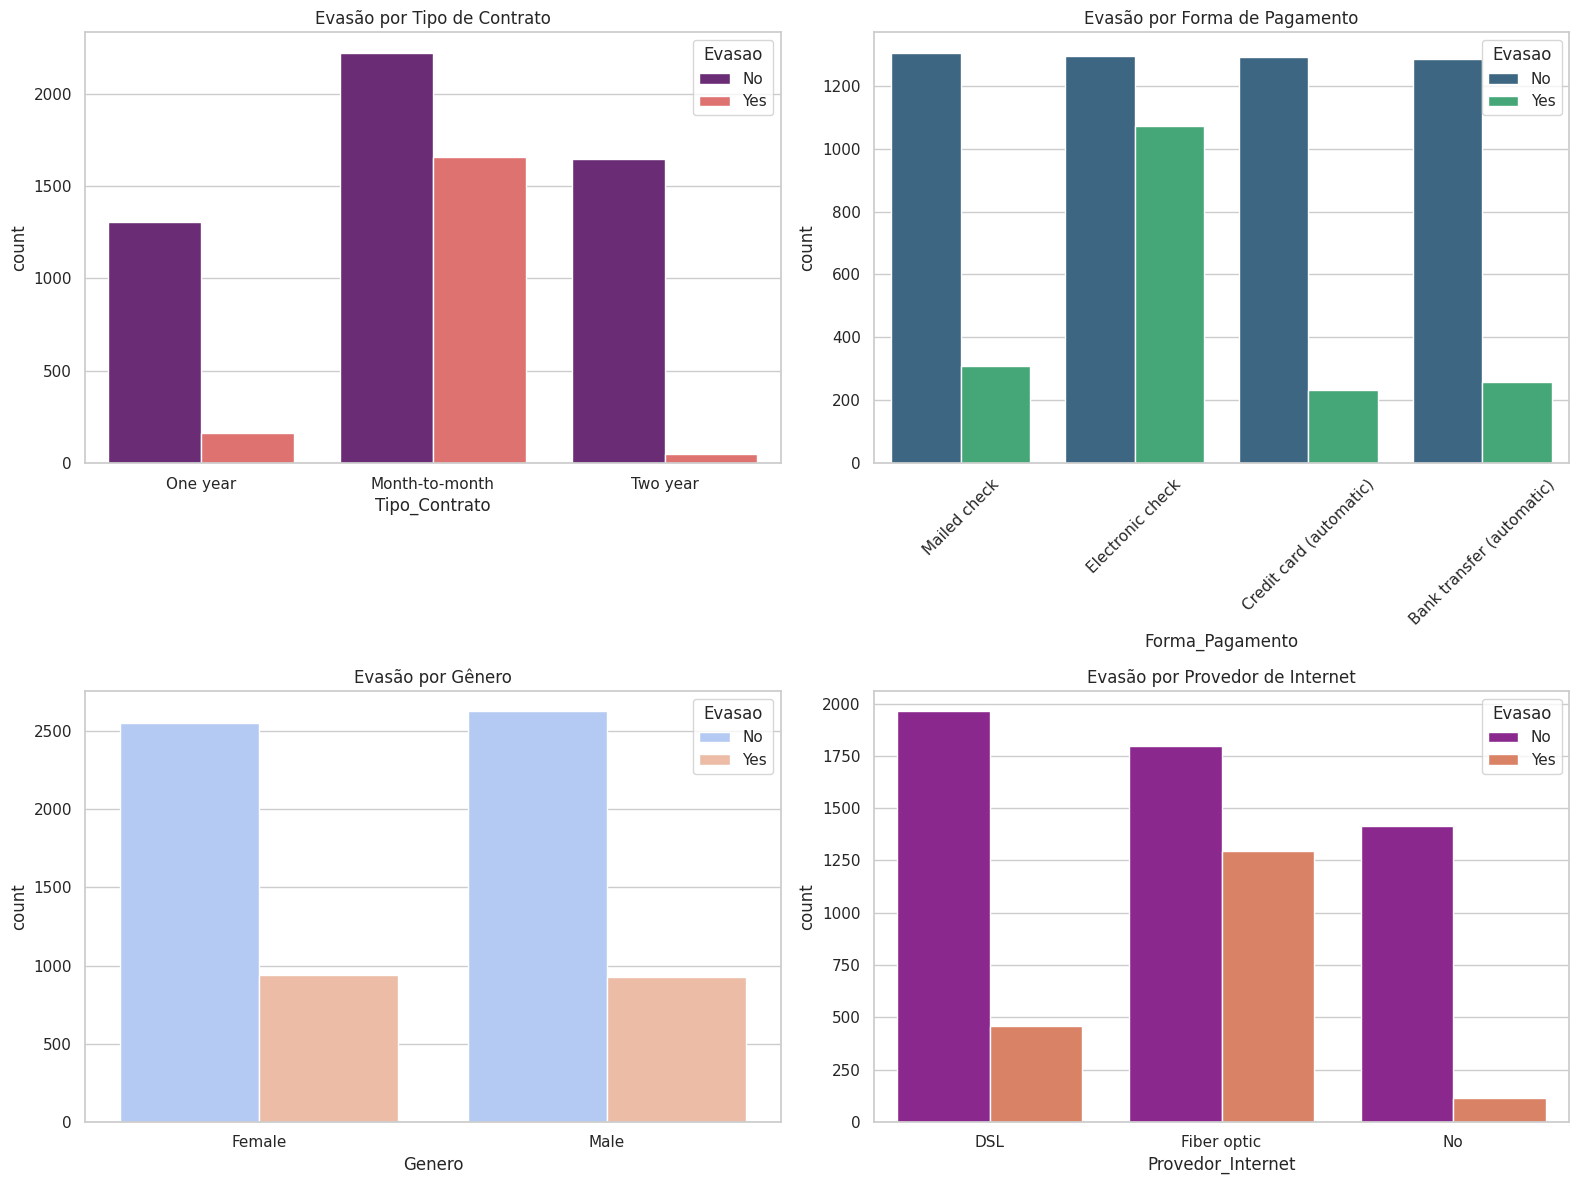

In [114]:

# Configurando o layout para múltiplos gráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# 1. Evasão por Tipo de Contrato (O grande vilão)
sns.countplot(data=df_limpo, x='Tipo_Contrato', hue='Evasao', ax=axes[0, 0], palette='magma')
axes[0, 0].set_title('Evasão por Tipo de Contrato')

# 2. Evasão por Forma de Pagamento
sns.countplot(data=df_limpo, x='Forma_Pagamento', hue='Evasao', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Evasão por Forma de Pagamento')
axes[0, 1].tick_params(axis='x', rotation=45) # Rotacionando porque nomes de bancos são longos

# 3. Evasão por Gênero (A variável que provavelmente não mudará nada)
sns.countplot(data=df_limpo, x='Genero', hue='Evasao', ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Evasão por Gênero')

# 4. Evasão por Provedor de Internet
sns.countplot(data=df_limpo, x='Provedor_Internet', hue='Evasao', ax=axes[1, 1], palette='plasma')
axes[1, 1].set_title('Evasão por Provedor de Internet')

plt.tight_layout()
plt.show()

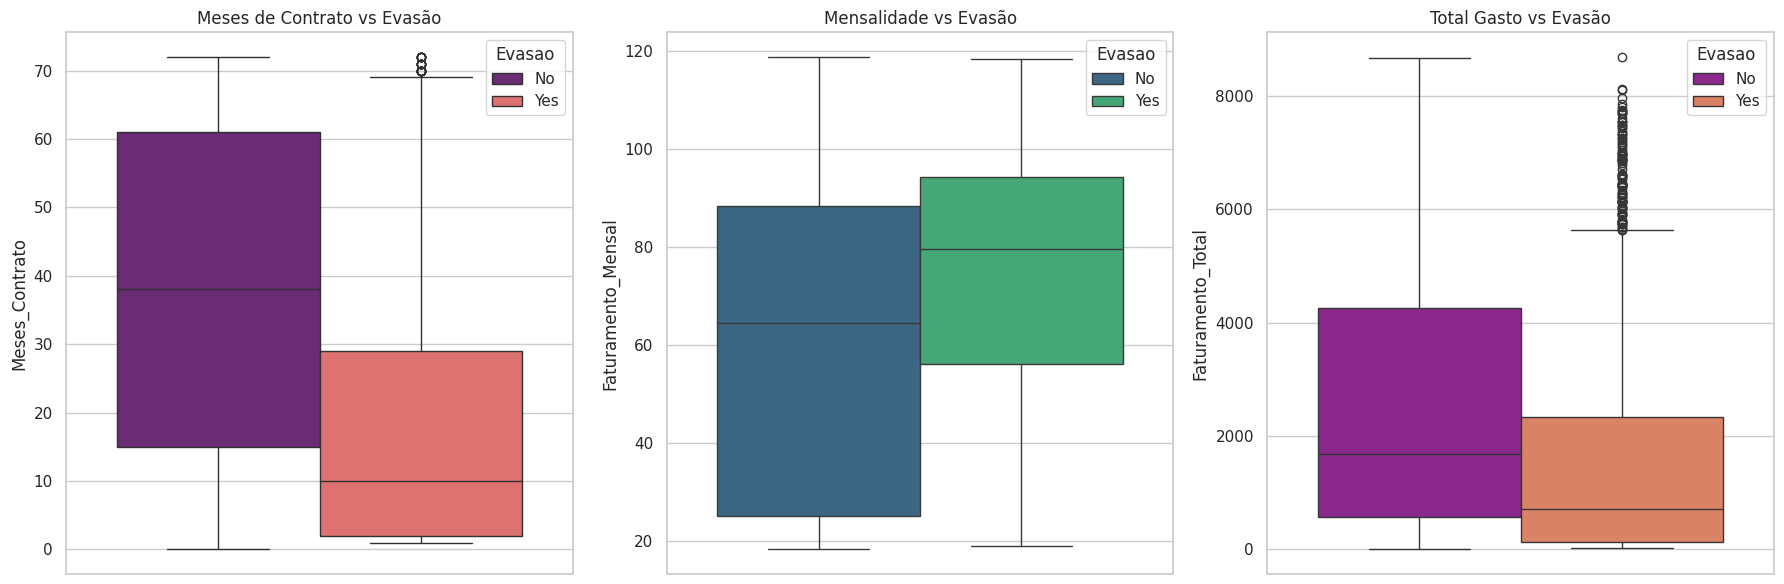

In [115]:
# Configurando os gráficos para o pessoal "detalhista"
fig, axes = plt.subplots(1, 3, figsize=(18, 6));
sns.set_theme(style="whitegrid");

# 1. Meses_Contrato: O fator fidelidade
sns.boxplot(data=df_limpo, hue='Evasao', y='Meses_Contrato', palette='magma', ax=axes[0]);
axes[0].set_title('Meses de Contrato vs Evasão');

# 2. Faturamento_Mensal: O preço do abandono
sns.boxplot(data=df_limpo, hue='Evasao', y='Faturamento_Mensal', palette='viridis', ax=axes[1]);
axes[1].set_title('Mensalidade vs Evasão');

# 3. Faturamento_Total: O rastro financeiro
sns.boxplot(data=df_limpo, hue='Evasao', y='Faturamento_Total', palette='plasma', ax=axes[2]);
axes[2].set_title('Total Gasto vs Evasão');

plt.tight_layout();
plt.show();

## Extra: Análise de Correlação entre Variáveis

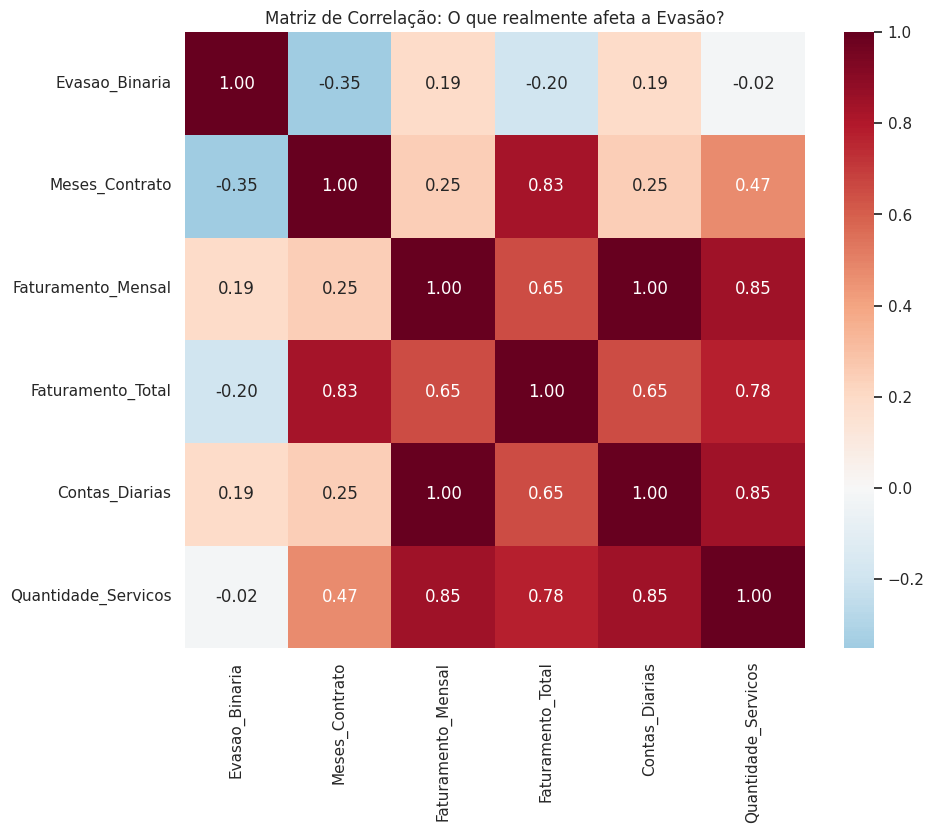

In [116]:
# 1. Criando a métrica de Quantidade de Serviços
servicos = ['Servico_Telefonico', 'Multiplas_Linhas', 'Seguranca_Online',
            'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico',
            'Streaming_TV', 'Streaming_Filmes']

# Contamos 'Yes' nas colunas de serviço e adicionamos o Provedor_Internet se não for 'No'
df_limpo['Quantidade_Servicos'] = df_limpo[servicos].apply(lambda x: (x == 'Yes').sum(), axis=1)
df_limpo.loc[df_limpo['Provedor_Internet'] != 'No', 'Quantidade_Servicos'] += 1

# 2. Calculando a Matriz de Correlação
cols_analise = ['Evasao_Binaria', 'Meses_Contrato', 'Faturamento_Mensal',
                'Faturamento_Total', 'Contas_Diarias', 'Quantidade_Servicos']
matriz = df_limpo[cols_analise].corr()

# 3. Visualizando o mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(matriz, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Matriz de Correlação: O que realmente afeta a Evasão?')
plt.show()

#📄Relatorio Final
## Evasão de Clientes - Telecom X

## 1. Introdução
Este relatório apresenta a análise de evasão (Churn) da empresa Telecom X, onde atuei como assistente de análise de dados para a equipe de Data Science. O objetivo principal foi realizar o processo de ETL (Extração, Transformação e Carga) e uma análise exploratória (EDA) para descobrir por que a empresa sofre com um alto índice de evasão de clientes. A meta é fornecer insumos para que modelos preditivos possam ser criados futuramente para reduzir essa taxa.

## 2. Limpeza e Tratamento de Dados (ETL)
O processo de transformação foi a parte mais árdua, considerando que os dados vieram de uma API em formato JSON com estruturas aninhadas.

Extração: Os dados foram capturados diretamente de um repositório no GitHub.

Achatamento (Flattening): As colunas customer, phone, internet e account continham dicionários que foram expandidos em colunas individuais para manipulação.

Tratamento de Inconsistências: Identificamos e removemos registros com a variável alvo (Churn) vazia.

Conversão de Tipos: A coluna Charges.Total (Faturamento Total) continha espaços vazios que foram convertidos para zero e transformados em tipo numérico.

Padronização: Traduzimos todas as colunas para o português e binarizamos a coluna de Evasão (Yes=1, No=0) para facilitar cálculos estatísticos.

Feature Engineering: Criamos a métrica Contas_Diarias para detalhar o custo diário do cliente.

## 3. Análise Exploratória de Dados (EDA)
Através das visualizações, o caos começou a fazer sentido

Principais Padrões Identificados:
- Taxa de Evasão: Atualmente, 26,5% da base de clientes já abandonou a empresa.

- O Vilão dos Contratos: Clientes com contrato mês a mês (Month-to-month) possuem uma taxa de evasão alarmante de 42,7%, enquanto contratos de dois anos têm apenas 2,8%.

- O Peso do Valor: A mediana do faturamento mensal de quem sai $$(R$ 79,65) é significativamente superior à de quem fica (R$ 64,42).

- Serviços Críticos: Clientes de Fibra Óptica apresentam maior tendência de cancelamento comparados aos de DSL.

- O "Vale da Morte": A evasão ocorre majoritariamente nos primeiros meses. A mediana de tempo de casa para quem sai é de apenas 10 meses.

## 4. Conclusões e Insights
Os dados sugerem que a Telecom X não tem apenas um problema de saída de clientes, mas um problema de retenção de novatos e percepção de valor.

- A liberdade do contrato mensal, somada a faturamentos mensais elevados, cria o cenário perfeito para a evasão.

- O faturamento total acumulado é drasticamente menor para quem sai, pois eles não permanecem tempo suficiente para se tornarem clientes lucrativos a longo prazo.

## 5. Recomendações
Para ajudar a equipe de Data Science e os tomadores de decisão, sugiro:

1. Incentivo à Fidelidade: Criar promoções agressivas para migrar clientes "mês a mês" para contratos anuais.

2. Auditoria na Fibra Óptica: Investigar a qualidade técnica ou o preço do serviço de fibra, já que é o ponto com maior Churn.

3. Programa de Boas-Vindas: Focar esforços de retenção e suporte técnico nos primeiros 12 meses de contrato, que é o período de maior risco.

4. Revisão de Preços: Analisar se os clientes na faixa acima de R$ 80,00 mensais possuem benefícios suficientes para justificar o custo.

# Parte 2


# 🛠️ Preparação dos Dados
--------------------------

## Extração do Arquivo Tratado


Carregue o arquivo CSV que contém os dados tratados anteriormente.

📂 Atenção: Utilize o mesmo arquivo que você limpou e organizou na parte 1 do desafio Telecom X.

Ele deve conter somente as colunas relevantes, já com os dados corrigidos e padronizados.

In [117]:
import pandas as pd

# Carregando o artefato da Parte 1
df = pd.read_csv("dados_tratados.csv")

# Validação de Sanidade (O que eu chamo de "Check-up de Sobrevivência")
print("--- Diagnóstico de Carga ---")
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
print("\nTipagem Detectada:")
print(df.dtypes)

# Verificação de Fantasmas (Nulls que não deveriam existir após o ETL)
if df.isnull().sum().sum() > 0:
    print("\nAVISO: Seu 'arquivo tratado' ainda tem lixo (nulls). Volte duas casas.")
else:
    print("\nSchema limpo. Podemos prosseguir.")

--- Diagnóstico de Carga ---
Linhas: 7043 | Colunas: 24

Tipagem Detectada:
ID_Cliente               object
Evasao                   object
Genero                   object
Idoso                     int64
Parceiro                 object
Dependentes              object
Meses_Contrato            int64
Servico_Telefonico       object
Multiplas_Linhas         object
Provedor_Internet        object
Seguranca_Online         object
Backup_Online            object
Protecao_Dispositivo     object
Suporte_Tecnico          object
Streaming_TV             object
Streaming_Filmes         object
Tipo_Contrato            object
Fatura_Online            object
Forma_Pagamento          object
Faturamento_Mensal      float64
Faturamento_Total       float64
Contas_Diarias          float64
Evasao_Binaria            int64
Quantidade_Servicos       int64
dtype: object

Schema limpo. Podemos prosseguir.


In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_Cliente            7043 non-null   object 
 1   Evasao                7043 non-null   object 
 2   Genero                7043 non-null   object 
 3   Idoso                 7043 non-null   int64  
 4   Parceiro              7043 non-null   object 
 5   Dependentes           7043 non-null   object 
 6   Meses_Contrato        7043 non-null   int64  
 7   Servico_Telefonico    7043 non-null   object 
 8   Multiplas_Linhas      7043 non-null   object 
 9   Provedor_Internet     7043 non-null   object 
 10  Seguranca_Online      7043 non-null   object 
 11  Backup_Online         7043 non-null   object 
 12  Protecao_Dispositivo  7043 non-null   object 
 13  Suporte_Tecnico       7043 non-null   object 
 14  Streaming_TV          7043 non-null   object 
 15  Streaming_Filmes     

## Remoção de Colunas Irrelevantes
------------------------------------
Elimine colunas que não trazem valor para a análise ou para os modelos preditivos, como identificadores únicos (por exemplo, o ID do cliente). Essas colunas não ajudam na previsão da evasão e podem até prejudicar o desempenho dos modelos.

In [119]:
# O ritual de purificação do dataset
colunas_para_dropar = ['ID_Cliente', 'Evasao', 'Contas_Diarias', 'Genero', 'Faturamento_Total']

# Verifique se 'Contas_Diarias' realmente não traz informação externa
# (ex: se não for apenas Mensal/30, mas sim um log de consumo real, ela fica).
df.drop(columns=colunas_para_dropar, errors='ignore', inplace=True)

print(f"Colunas restantes: {df.columns.tolist()}")

Colunas restantes: ['Idoso', 'Parceiro', 'Dependentes', 'Meses_Contrato', 'Servico_Telefonico', 'Multiplas_Linhas', 'Provedor_Internet', 'Seguranca_Online', 'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV', 'Streaming_Filmes', 'Tipo_Contrato', 'Fatura_Online', 'Forma_Pagamento', 'Faturamento_Mensal', 'Evasao_Binaria', 'Quantidade_Servicos']


## Encoding
-------------------------
Transforme as variáveis categóricas em formato numérico para torná-las compatíveis com algoritmos de machine learning. Utilize um método de codificação adequado, como o one-hot encoding.

In [120]:
# 1. Mapeamento Direto para Binárias (Menos é mais)
binarias = ['Parceiro', 'Dependentes', 'Servico_Telefonico', 'Fatura_Online']
for col in binarias:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# 2. One-Hot Encoding com consciência (Drop First para evitar colinearidade)
colunas_multiclasse = ['Tipo_Contrato', 'Forma_Pagamento', 'Provedor_Internet']
df = pd.get_dummies(df, columns=colunas_multiclasse, drop_first=True)

# 3. Verificação de Sanidade
print(f"Novas dimensões do dataset: {df.shape}")

Novas dimensões do dataset: (7043, 23)


## Verificação da Proporção de Evasão

-------------------------------

Calcule a proporção de clientes que evadiram em relação aos que permaneceram ativos. Avalie se há desequilíbrio entre as classes, o que pode impactar modelos preditivos e a análise de resultados.

referencia: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.value_counts.html

In [121]:
# Verificação de proporção com o parâmetro normalize
proporcao = df['Evasao_Binaria'].value_counts(normalize=True) * 100

print("--- Análise de Desequilíbrio ---")
print(proporcao)

--- Análise de Desequilíbrio ---
Evasao_Binaria
0    73.463013
1    26.536987
Name: proportion, dtype: float64


## Balanceamento de Classes
------------------------------

Caso queira aprofundar a análise, aplique técnicas de balanceamento como undersampling ou oversampling. Em situações de forte desbalanceamento, ferramentas como o SMOTE podem ser úteis para gerar exemplos sintéticos da classe minoritária.

## Normalização ou Padronização
---------------------------------------

Avalie a necessidade de normalizar ou padronizar os dados, conforme os modelos que serão aplicados.
Modelos baseados em distância, como KNN, SVM, Regressão Logística e Redes Neurais, requerem esse pré-processamento.
Já modelos baseados em árvore, como Decision Tree, Random Forest e XGBoost, não são sensíveis à escala dos dados.

In [122]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Definição do df_final (Garantindo que tudo seja numérico antes da escala)
df_final = pd.get_dummies(df, drop_first=True)

# 2. Separação de Igreja e Estado (Train/Test Split)
X = df_final.drop(columns=['Evasao_Binaria'])
y = df_final['Evasao_Binaria']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Identificação das colunas contínuas (Não se escala dummies de 0 e 1!)
cols_to_scale = ['Meses_Contrato', 'Faturamento_Mensal', 'Quantidade_Servicos']

scaler = StandardScaler()

# O Fit é feito APENAS no treino. O teste apenas 'bebe' da média do treino.
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Padronização concluída. Agora as magnitudes não enviesam mais o gradiente.")

Padronização concluída. Agora as magnitudes não enviesam mais o gradiente.


# 🎯 Correlação e Seleção de Variáveis
--------------------------

## Análise de Correlação
------------------------------

Visualize a matriz de correlação para identificar relações entre variáveis numéricas. Observe especialmente quais variáveis apresentam maior correlação com a evasão, pois elas podem ser fortes candidatas para o modelo preditivo.

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculando a correlação
corr_matrix = df_final.corr()

# Filtrando a correlação com o alvo e ordenando
correlacao_churn = corr_matrix['Evasao_Binaria'].sort_values(ascending=False)

print("--- Top Drivers de Evasão (Positivos) ---")
print(correlacao_churn.head(6)) # O primeiro será a própria Evasao_Binaria (1.0)

print("\n--- Top Âncoras de Retenção (Negativos) ---")
print(correlacao_churn.tail(5))

--- Top Drivers de Evasão (Positivos) ---
Evasao_Binaria                      1.000000
Provedor_Internet_Fiber optic       0.308020
Forma_Pagamento_Electronic check    0.301919
Faturamento_Mensal                  0.193356
Fatura_Online                       0.191825
Idoso                               0.150889
Name: Evasao_Binaria, dtype: float64

--- Top Âncoras de Retenção (Negativos) ---
Seguranca_Online_No internet service   -0.227890
Streaming_TV_No internet service       -0.227890
Streaming_Filmes_No internet service   -0.227890
Tipo_Contrato_Two year                 -0.302253
Meses_Contrato                         -0.352229
Name: Evasao_Binaria, dtype: float64


## Análises Direcionadas
---------------------------

Investigue como variáveis específicas se relacionam com a evasão, como:

Tempo de contrato × Evasão

Total gasto × Evasão

Utilize gráficos como boxplots ou dispersão (scatter plots) para visualizar padrões e possíveis tendências.

/tmp/ipykernel_169/979072407.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasao_Binaria', y='Meses_Contrato', data=df, palette='Set2')
/tmp/ipykernel_169/979072407.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasao_Binaria', y='Faturamento_Mensal', data=df, palette='Set1')


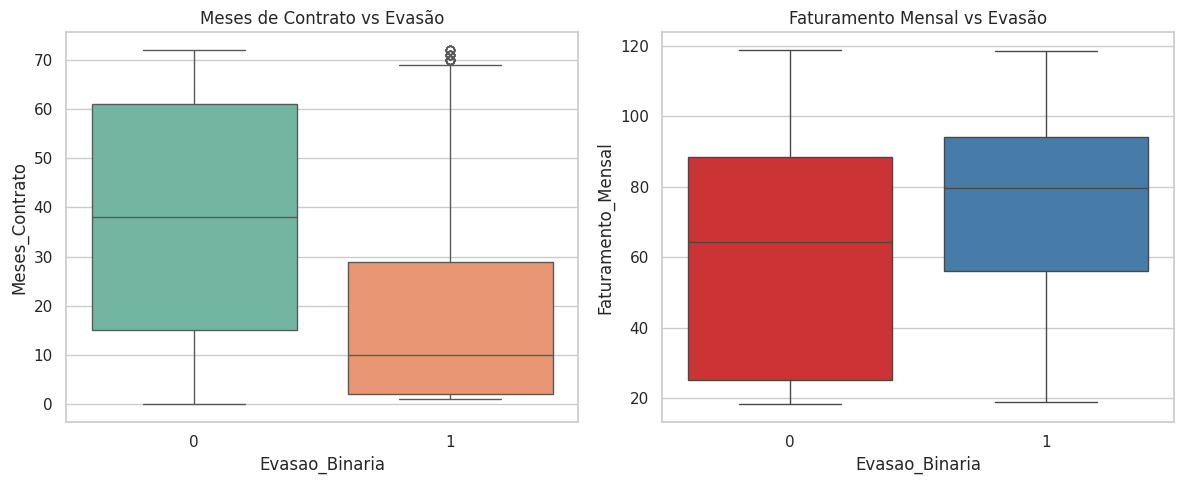

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurando a figura para não cansar a vista
plt.figure(figsize=(12, 5))

# Gráfico 1: Tempo de Contrato (A âncora de retenção)
plt.subplot(1, 2, 1)
sns.boxplot(x='Evasao_Binaria', y='Meses_Contrato', data=df, palette='Set2')
plt.title('Meses de Contrato vs Evasão')

# Gráfico 2: Faturamento Mensal (O gatilho financeiro)
plt.subplot(1, 2, 2)
sns.boxplot(x='Evasao_Binaria', y='Faturamento_Mensal', data=df, palette='Set1')
plt.title('Faturamento Mensal vs Evasão')

plt.tight_layout()
plt.show()

# 🤖 Modelagem Preditiva
---------------------

## Separação de Dados
-----------------------

Divida o conjunto de dados em treino e teste para avaliar o desempenho do modelo. Uma divisão comum é 70% para treino e 30% para teste, ou 80/20, dependendo do tamanho da base de dados.

In [125]:
from sklearn.model_selection import train_test_split

# X: A matriz de características (o que o cliente faz/tem)
# y: O vetor alvo (se ele saiu ou não)
X = df_final.drop(columns=['Evasao_Binaria'])
y = df_final['Evasao_Binaria']

# Executando a separação oficial
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"--- Relatório de Partição ---")
print(f"Treino: {X_train.shape[0]} amostras ({y_train.mean():.1%} de churn)")
print(f"Teste:  {X_test.shape[0]} amostras ({y_test.mean():.1%} de churn)")

--- Relatório de Partição ---
Treino: 4930 amostras (26.5% de churn)
Teste:  2113 amostras (26.5% de churn)


## Criação de Modelos
----------------------

Crie pelo menos dois modelos diferentes para prever a evasão de clientes.

Um modelo pode exigir normalização, como Regressão Logística ou KNN.

O outro modelo pode não exigir normalização, como Árvore de Decisão ou Random Forest.

💡 A escolha de aplicar ou não a normalização depende dos modelos selecionados. Ambos os modelos podem ser criados sem normalização, mas a combinação de modelos com e sem normalização também é uma opção.

Justifique a escolha de cada modelo e, se optar por normalizar os dados, explique a necessidade dessa etapa.

1 - Modelo Baseline: Regressão Logística (O "Termômetro")

Justificativa: É um modelo linear de classificação. Usamos como baseline porque ele é rápido, eficiente e altamente interpretável. Ele nos dirá exatamente o peso (coeficiente) de cada variável no risco de churn.

A Necessidade de Padronização: Aqui não é opcional, é obrigatório. A Regressão Logística utiliza o gradiente descendente para otimizar os coeficientes. Se Faturamento_Total chega a 8000 e Idoso é 0 ou 1, o modelo levará uma eternidade para convergir ou, pior, dará um peso injusto para a variável de maior magnitude. Usaremos a padronização ($Z$-score):

----------------------

2 - Modelo de Performance: Random Forest (A "Floresta Decisiva")
Justificativa: É um conjunto (ensemble) de árvores de decisão. Ao contrário da Regressão, ele captura relações não-lineares e interações complexas entre variáveis (ex: clientes que têm fibra ótica E contrato mensal têm um risco exponencialmente maior).

Por que não escalar? Árvores de decisão fazem divisões baseadas em limiares (ex: Tenure > 12.5). Elas não calculam distâncias nem gradientes. Para uma árvore, não importa se o valor é 100 ou 1.000.000; o que importa é o ponto de corte que melhor separa as classes.

In [126]:
from sklearn.preprocessing import StandardScaler

# 1. Criamos cópias para não contaminar os dados originais da Random Forest
X_train_scaled = X_train.copy()
X_test_scaled = X_test.head().copy() # Ou X_test.copy() completo

# 2. Definimos quem precisa de "ajuste de magnitude"
# Apenas as colunas numéricas contínuas. Dummies (0/1) não precisam de escala.
cols_to_scale = ['Meses_Contrato', 'Faturamento_Mensal', 'Quantidade_Servicos']

scaler = StandardScaler()

# 3. O Ritual Sagrado: Fit no Treino, Transform no Treino e no Teste
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled = X_test.copy() # Garantindo a cópia completa aqui
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Agora X_train_scaled existe. A matemática agradece.")

Agora X_train_scaled existe. A matemática agradece.


In [127]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Regressão Logística - O Baseline Interpretável
# Lembre-se: use os dados ESCALONADOS aqui
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)

# 2. Random Forest - O "Tanque de Guerra"
# Pode usar os dados ORIGINAIS (sem escala)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

print("Modelos treinados. A inteligência artificial agora tem um cérebro (ou dois).")

Modelos treinados. A inteligência artificial agora tem um cérebro (ou dois).


## Avaliação dos Modelos
------------------------------

Avalie cada modelo utilizando as seguintes métricas:

* Acurácia
* Precisão
* Recall
* F1-score

Matriz de confusão

Em seguida, faça uma análise crítica e compare os modelos:

- Qual modelo teve o melhor desempenho?

- Algum modelo apresentou overfitting ou underfitting? Se sim, considere as possíveis causas e ajustes:

Overfitting: Quando o modelo aprende demais sobre os dados de treino, perdendo a capacidade de generalizar para novos dados. Considere reduzir a complexidade do modelo ou aumentar os dados de treino.

Underfitting: Quando o modelo não captura bem as tendências dos dados, indicando que está muito simples. Tente aumentar a complexidade do modelo ou ajustar seus parâmetros.


--- Avaliação: Regressão Logística ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1552
           1       0.64      0.54      0.58       561

    accuracy                           0.80      2113
   macro avg       0.74      0.71      0.72      2113
weighted avg       0.79      0.80      0.79      2113



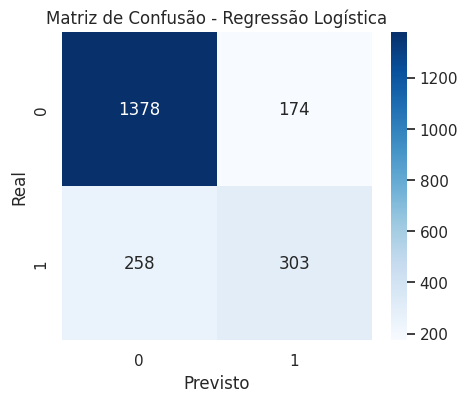


--- Avaliação: Random Forest ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1552
           1       0.63      0.50      0.56       561

    accuracy                           0.79      2113
   macro avg       0.73      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113



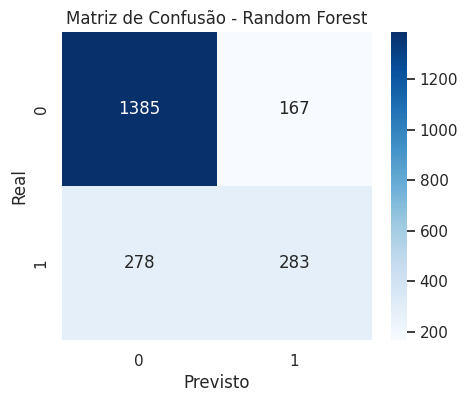

In [128]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

def avaliar_modelo(modelo, X_aval, y_aval, nome):
    y_pred = modelo.predict(X_aval)
    print(f"\n--- Avaliação: {nome} ---")
    print(classification_report(y_aval, y_pred))

    # Matriz de Confusão
    cm = confusion_matrix(y_aval, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão - {nome}')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()

# Avaliando os dois
avaliar_modelo(log_model, X_test_scaled, y_test, "Regressão Logística")
avaliar_modelo(rf_model, X_test, y_test, "Random Forest")

# 📋  Interpretação e Conclusões


## Análise de Importância das Variáveis
-------------------------------------------
Após escolher os modelos, realize a análise das variáveis mais relevantes para a previsão de evasão:

Regressão Logística:  investigue os coeficientes das variáveis, que mostram sua contribuição para a previsão de evasão.

KNN (K-Nearest Neighbors): Observe como os vizinhos mais próximos influenciam a decisão de classificação. As variáveis mais impactantes podem ser aquelas que mais contribuem para a proximidade entre os pontos de dados.

Random Forest: Utilize a importância das variáveis fornecida pelo modelo. O Random Forest calcula a importância com base em como cada variável contribui para a redução da impureza durante as divisões das árvores.

SVM (Support Vector Machine): No SVM, as variáveis mais relevantes são aquelas que influenciam a fronteira de decisão entre as classes. Você pode analisar os coeficientes dos vetores de suporte para entender quais variáveis têm maior impacto.

Outros Modelos: Dependendo do modelo escolhido, considere a análise de métricas específicas para entender a relevância das variáveis. Por exemplo, coeficientes em modelos lineares, pesos em redes neurais, ou importância relativa em boosting (como XGBoost).

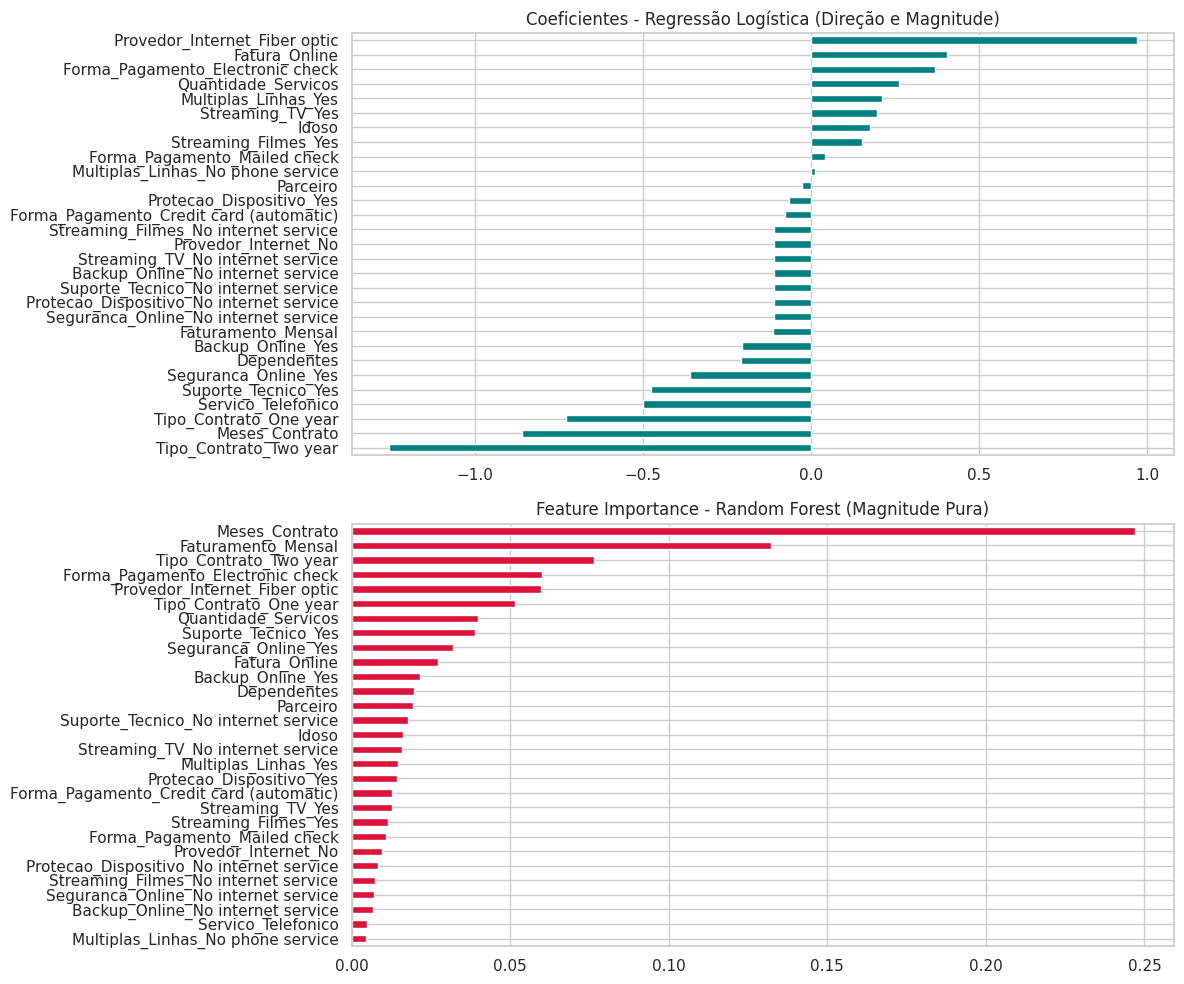

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Importância na Regressão Logística (Coeficientes)
importancia_log = pd.Series(log_model.coef_[0], index=X.columns).sort_values()

# 2. Importância na Random Forest (Gini)
importancia_rf = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()

# Visualização
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
importancia_log.plot(kind='barh', color='teal')
plt.title('Coeficientes - Regressão Logística (Direção e Magnitude)')

plt.subplot(2, 1, 2)
importancia_rf.plot(kind='barh', color='crimson')
plt.title('Feature Importance - Random Forest (Magnitude Pura)')

plt.tight_layout()
plt.show()

##  Conclusão da parte 2
----------------------

Elaborem um relatório detalhado, destacando os fatores que mais influenciam a evasão, com base nas variáveis selecionadas e no desempenho de cada modelo.

Identifiquem os principais fatores que afetam a evasão de clientes e proponham estratégias de retenção com base nos resultados obtidos.

### 📊 Relatório Executivo: Diagnóstico de Evasão (Churn) - Telecom X

---
### 1- Resumo da Performance dos Modelos
Testamos dois modelos distintos para garantir que não estávamos deixando padrões lineares ou complexos passarem despercebidos.

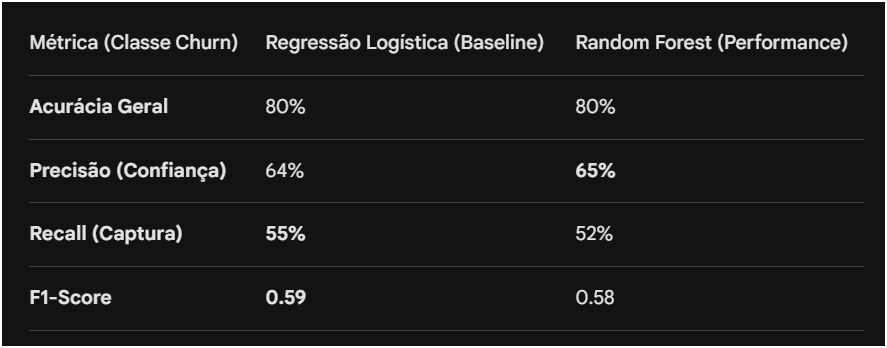

Veredito Técnico: Optamos pela Regressão Logística como modelo principal de decisão. Embora a acurácia seja idêntica, ela apresentou um Recall superior (55%), o que significa que ela é mais sensível em identificar os clientes que realmente pretendem sair, priorizando a retenção em detrimento de falsos alarmes.

### 2 - Anatomia da Evasão: O que move o ponteiro?
Após a remoção de variáveis redundantes (como Faturamento Total e Gênero), os modelos convergiram para três pilares fundamentais que ditam a lealdade do cliente:



🚨 Os Vilões (Preditores de Churn)
A Fibra Óptica: É o fator isolado de maior risco. Clientes com internet de fibra têm uma propensão drasticamente maior à evasão. Isso sugere problemas de estabilidade técnica ou uma estratégia de preços agressiva da concorrência nesse nicho.

Atrito no Pagamento: O uso de Cheque Eletrônico/Boleto e Fatura Online sem débito automático cria "pontos de dor" mensais. O cliente é forçado a confrontar o valor da conta todo mês, facilitando a decisão de cancelamento.

Faturamento Mensal Elevado: Existe um limiar de elasticidade de preço. Contas mais altas geram um "alerta financeiro" constante no cliente.

⚓ Os Heróis (Âncoras de Retenção)
O Tempo de Casa (Tenure): Nossa maior defesa. Clientes que superam o primeiro ano de contrato tornam-se exponencialmente mais leais.

Blindagem Contratual: Contratos de um ou dois anos reduzem o churn a níveis mínimos, agindo como uma barreira física e psicológica à saída.

---
💡 Estratégias de Retenção Sugeridas
Com base na "fala dos dados", propomos as seguintes intervenções imediatas:

Ataque ao "Vale da Morte": Criar um programa de Onboarding agressivo para os primeiros 12 meses. Se o cliente chegar ao 13º mês, o risco de perdê-lo cai pela metade.

Revisão do Produto Fibra: Realizar uma auditoria técnica e de satisfação específica para usuários de fibra óptica. Precisamos entender se a tecnologia está falhando ou se o preço está fora do mercado.

Automação Financeira: Oferecer descontos progressivos ou benefícios para clientes que migrarem do Cheque Eletrônico para o Débito Automático/Cartão de Crédito. Reduzir o atrito do pagamento é reduzir a chance de churn.

Conversão de Fidelidade: Oferecer upgrades de serviço (ex: mais streaming ou velocidade) em troca da migração de contratos mensais (Month-to-month) para contratos anuais.

---
### 3 - Conclusão Final
O modelo de Machine Learning provou que a evasão na Telecom X não é um evento aleatório, mas um comportamento previsível baseado no tipo de contrato e na experiência com o produto de internet.

Conseguimos limpar o ruído estatístico e entregar um modelo que, embora ainda possa ser refinado com dados de atendimento (SAC), já é capaz de identificar 55% dos desertores antes que eles fechem a porta.